**Importation des bibliothèques**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Importation des données en format csv**


In [ ]:
file_path="/content/drive/MyDrive/GoldPrice/CopyOfGold Price.csv"
data=pd.read_csv(file_path)

**EDA(Exploratory Data Analysis)**

In [ ]:
data.head()

,Date,Price,Open,High,Low,Volume,Chg%
0,2024-11-06,77030,78300,78570,77030,0,-1.86
1,2024-11-05,78490,78224,78670,78160,0,0.11
2,2024-11-04,78401,78498,78642,78237,0,-0.54
3,2024-11-01,78829,78650,78887,78550,0,0.64
4,2024-10-31,78326,79264,79999,77803,90,-1.17


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2806 non-null   object 
 1   Price   2806 non-null   int64  
 2   Open    2806 non-null   int64  
 3   High    2806 non-null   int64  
 4   Low     2806 non-null   int64  
 5   Volume  2806 non-null   int64  
 6   Chg%    2806 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 153.6+ KB


In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')
data.set_index('Date', inplace=True)

In [ ]:
data.head()

,Price,Open,High,Low,Volume,Chg%
Date,,,,,,
2014-01-01,29542,29435,29598,29340,2930,0.25
2014-01-02,29975,29678,30050,29678,3140,1.47
2014-01-03,29727,30031,30125,29539,3050,-0.83
2014-01-04,29279,29279,29279,29279,0,-1.51
2014-01-06,29119,29300,29395,29051,24380,-0.55


**Division des données**

In [ ]:
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:]

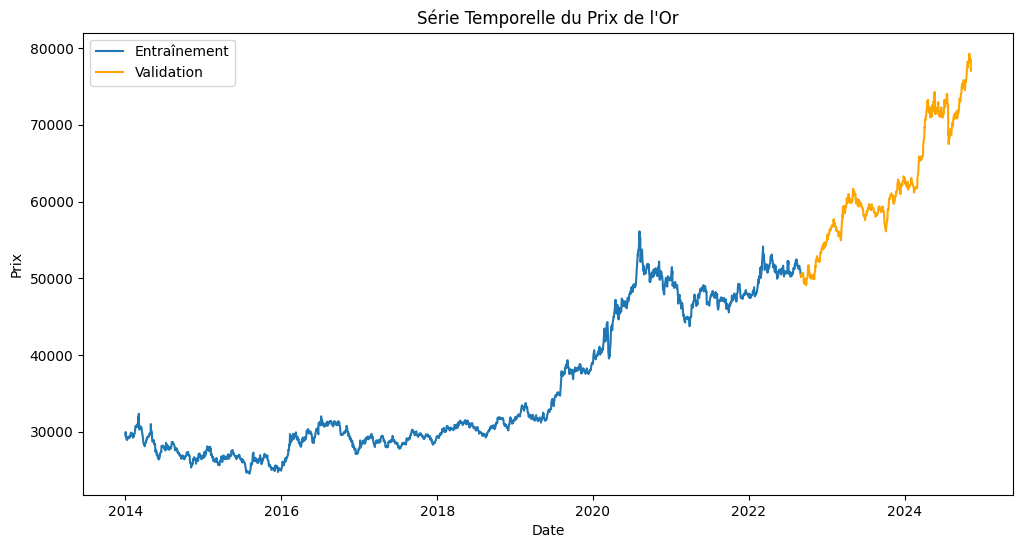

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_data['Price'], label='Entraînement')
plt.plot(val_data['Price'], label='Validation', color='orange')
plt.title("Série Temporelle du Prix de l'Or")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.show()

**Décomposition de la série**

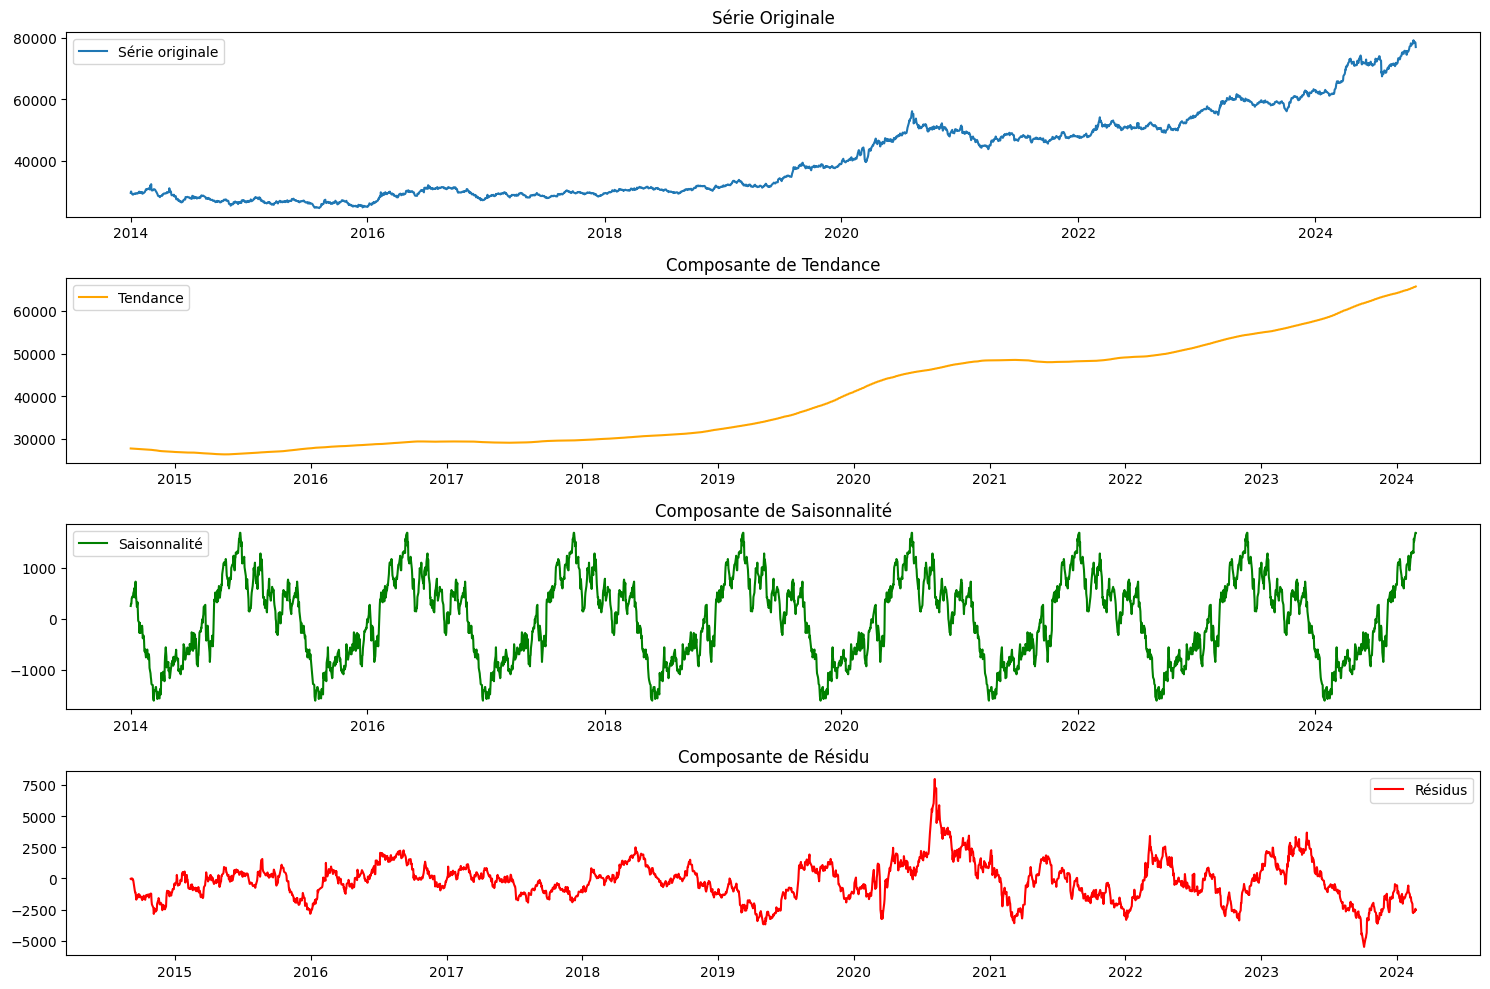

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['Price'], model='additive', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(15, 10))

plt.subplot(4, 1, 1)
plt.plot(data['Price'], label='Série originale')
plt.title('Série Originale')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Tendance', color='orange')
plt.title('Composante de Tendance')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Saisonnalité', color='green')
plt.title('Composante de Saisonnalité')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Résidus', color='red')
plt.title('Composante de Résidu')
plt.legend()

plt.tight_layout()
plt.show()

**ADF test et différenciation de la série**

In [ ]:
from statsmodels.tsa.stattools import adfuller

resultat_adf = adfuller(train_data['Price'])
print(f"ADF Statistic: {resultat_adf[0]}")
print(f"p-value: {resultat_adf[1]}")
print(f"Critères de stationnarité (1%, 5%, 10%): {resultat_adf[4]}")

if resultat_adf[1] < 0.05:
    print("La série est stationnaire (p-value < 0.05).")
else:
    print("La série n'est pas stationnaire (p-value >= 0.05).")

ADF Statistic: 0.028857006864826954
p-value: 0.9608544660686428
Critères de stationnarité (1%, 5%, 10%): {'1%': -3.433287122798914, '5%': -2.8628375359198617, '10%': -2.5674607403348455}
La série n'est pas stationnaire (p-value >= 0.05).


In [ ]:
train_diff = train_data.diff().dropna()
resultat_adf_diff = adfuller(train_diff['Price'])

print(f"ADF Statistic (différenciée): {resultat_adf_diff[0]}")
print(f"p-value (différenciée): {resultat_adf_diff[1]}")

if resultat_adf_diff[1] < 0.05:
    print("La série est maintenant stationnaire après différenciation.")
else:
    print("La série n'est toujours pas stationnaire après différenciation.")

ADF Statistic (différenciée): -13.224988830704808
p-value (différenciée): 9.843118617988137e-25
La série est maintenant stationnaire après différenciation.


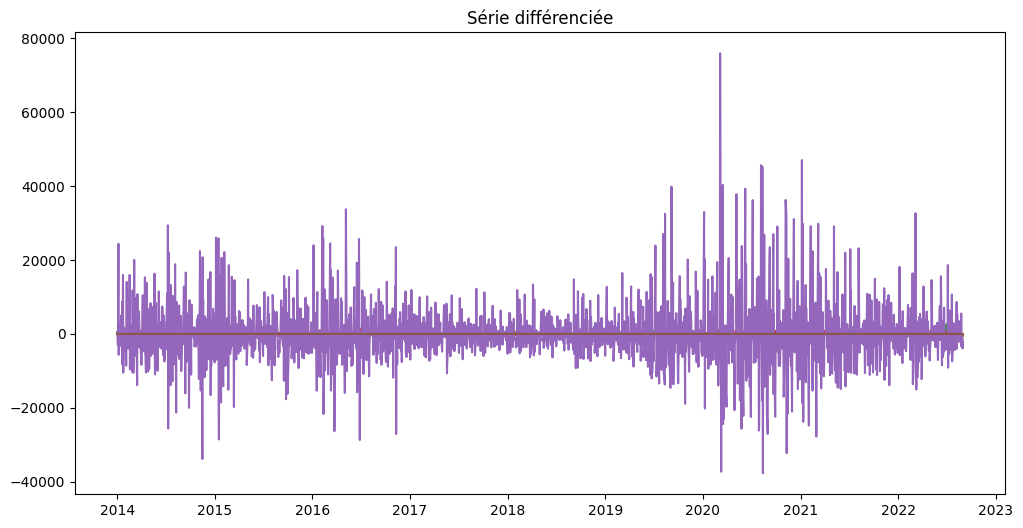

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_diff)
plt.title("Série différenciée")
plt.show()

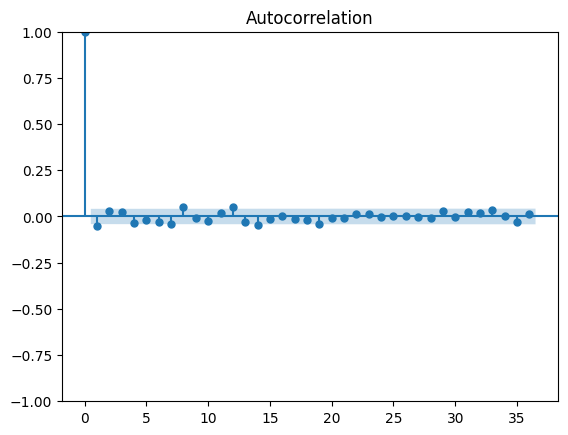

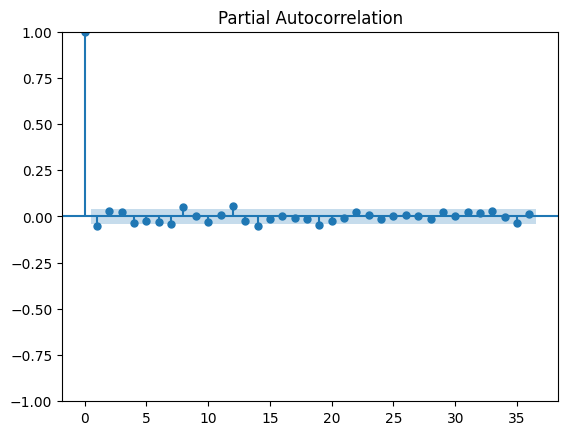

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train_diff['Price'], lags=36)
plot_pacf(train_diff['Price'], lags=36)
plt.show()

**Modèles concurrents**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
models = [
    ARIMA(train_data['Price'], order=(1, 1, 1)),
    ARIMA(train_data['Price'], order=(2, 1, 0)),
    ARIMA(train_data['Price'], order=(1, 1, 2))
]

for i, model in enumerate(models):
    fitted_model = model.fit()
    print(f"Modèle {i+1} : AIC = {fitted_model.aic}")

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Modèle 1 : AIC = 32304.037590685668
Modèle 2 : AIC = 32303.08839254106
Modèle 3 : AIC = 32304.525524907134


**Choix du modèle finale**

In [ ]:
final_model = ARIMA(train_data['Price'], order=(2, 1, 0)).fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


**Validation des coefficients**

In [ ]:
print("Estimation des paramètres...")
print(final_model.summary())


Estimation des paramètres...
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2244
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -16148.544
Date:                Sat, 11 Jan 2025   AIC                          32303.088
Time:                        09:19:43   BIC                          32320.235
Sample:                             0   HQIC                         32309.348
                               - 2244                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0419      0.014     -2.924      0.003      -0.070      -0.014
ar.L2          0.0268      0.013      2.098      0.036       0.002       0.052
sigma2      1.049e+05 

In [ ]:
coefficients = final_model.params
t_stats = final_model.tvalues
print("\nCoefficients estimés et t de Student :")
for coef, t_stat in zip(coefficients.index, t_stats):
    print(f"{coef}: Coefficient = {coefficients[coef]:.4f}, t-Stat = {t_stat:.2f}")

valid_coefficients = np.all(np.abs(t_stats) > 1.96)
print("\nTous les coefficients valides :", "Oui" if valid_coefficients else "Non")


Coefficients estimés et t de Student :
ar.L1: Coefficient = -0.0419, t-Stat = -2.92
ar.L2: Coefficient = 0.0268, t-Stat = 2.10
sigma2: Coefficient = 104854.0466, t-Stat = 73.70

Tous les coefficients valides : Oui


**Analyse des résidus**

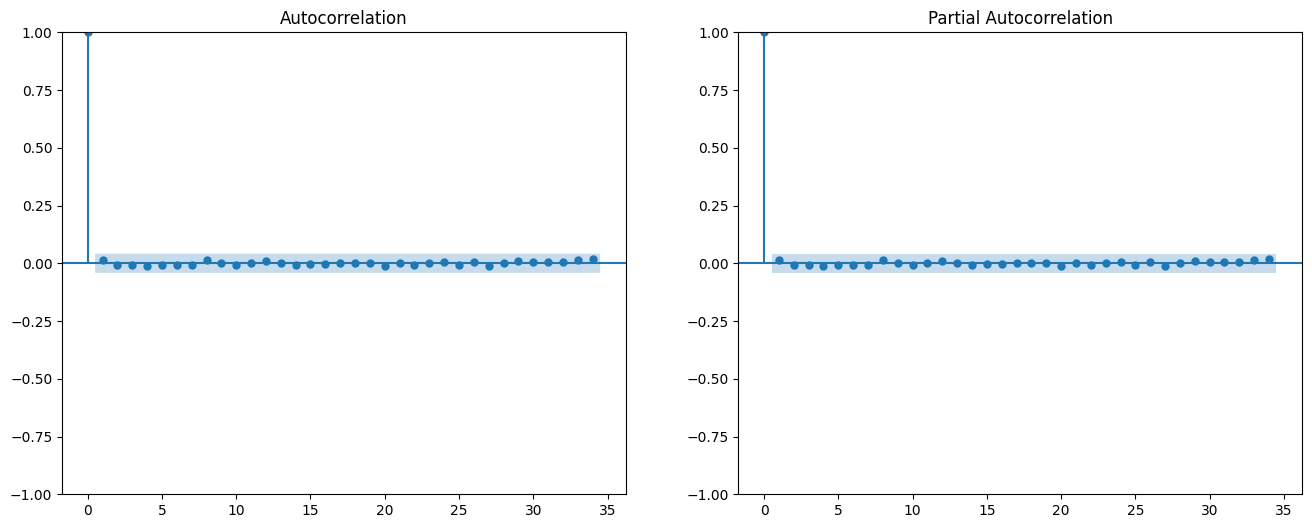

In [ ]:
import statsmodels.api as sm

residuals = final_model.resid

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sm.graphics.tsa.plot_acf(residuals, ax=axes[0])
sm.graphics.tsa.plot_pacf(residuals, ax=axes[1], method='ywm')
plt.show()

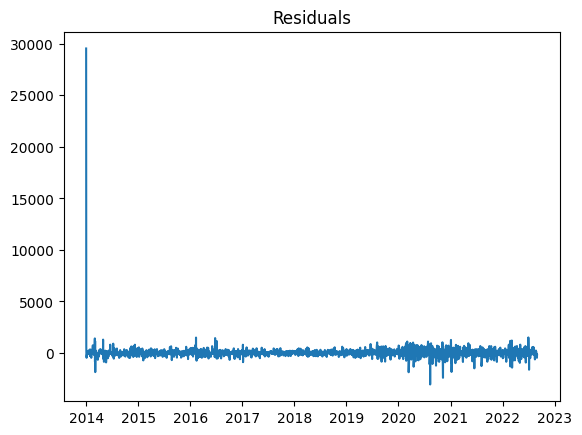

In [ ]:
plt.plot(residuals)
plt.title("Residuals")
plt.show()


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)


     lb_stat  lb_pvalue
10  2.106669   0.995455


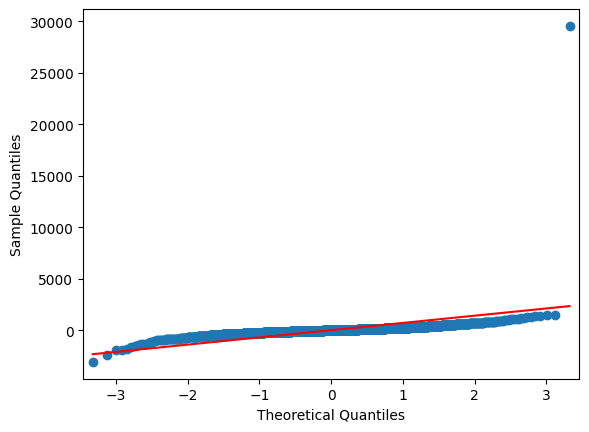

In [ ]:
sm.qqplot(residuals, line='s')
plt.show()


**Validation du modèle**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


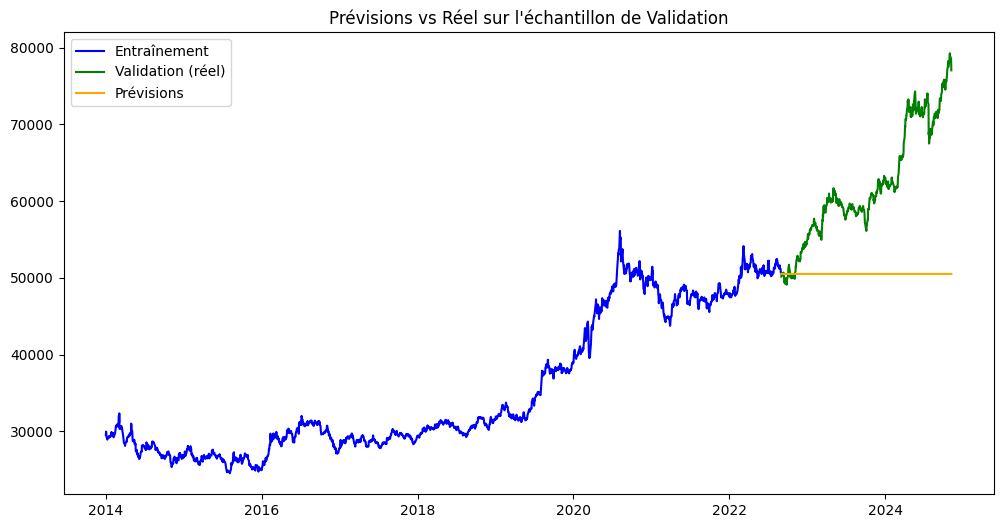

In [ ]:
n_steps = len(val_data)
forecast = final_model.forecast(steps=n_steps)
forecast_index = val_data.index
plt.figure(figsize=(12, 6))

plt.plot(train_data.index, train_data['Price'], label='Entraînement', color='blue')
plt.plot(val_data.index, val_data['Price'], label='Validation (réel)', color='green')

plt.plot(forecast_index, forecast, label='Prévisions', color='orange')

plt.legend()
plt.title('Prévisions vs Réel sur l\'échantillon de Validation')
plt.show()

**Prévision**

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


                Forecast      Lower CI      Upper CI
Date                                                
2024-11-07  50514.733526  49880.074167  51149.392885
2024-11-08  50510.107790  49631.171456  51389.044125
2024-11-09  50510.160648  49430.987040  51589.334255
2024-11-10  50510.034574  49263.093514  51756.975633
2024-11-11  50510.041273  49115.124977  51904.957569


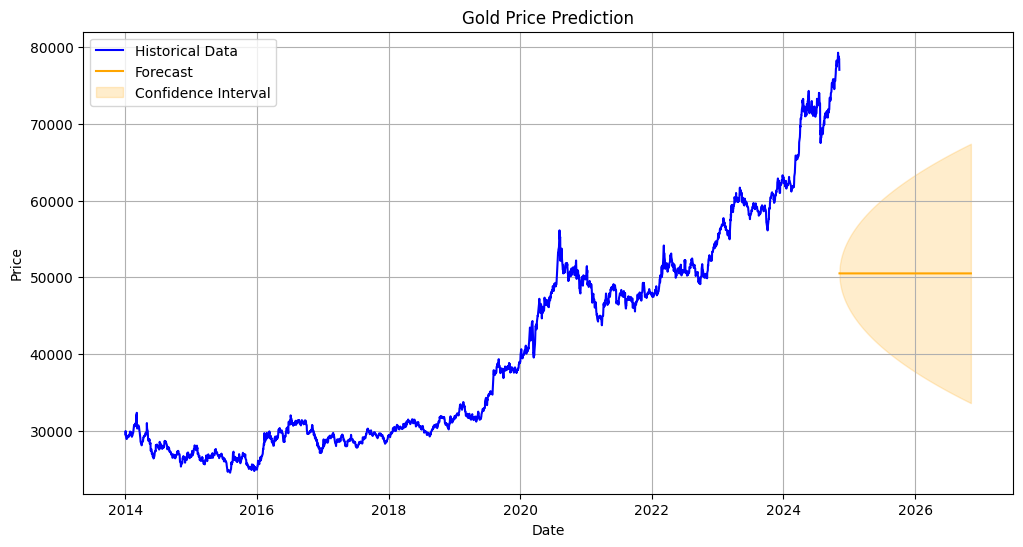

In [ ]:

forecast_steps = 365 * 2
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast = final_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast_mean.values,
    "Lower CI": forecast_conf_int.iloc[:, 0].values,
    "Upper CI": forecast_conf_int.iloc[:, 1].values
})

forecast_df.set_index("Date", inplace=True)
print(forecast_df.head())
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Price'], label="Historical Data", color="blue")
plt.plot(forecast_df.index, forecast_df["Forecast"], label="Forecast", color="orange")
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower CI"],
    forecast_df["Upper CI"],
    color="orange",
    alpha=0.2,
    label="Confidence Interval"
)
plt.title("Gold Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()
